In [1]:
import pandas as pd

In [2]:
from gensim.models import Word2Vec

In [3]:
from sklearn.metrics import f1_score

In [4]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

torch._inductor.config.triton.cudagraph_skip_dynamic_graphs=True
torch.backends.fp32_precision = "tf32"
torch.backends.cudnn.fp32_precision = "tf32"
torch.backends.cudnn.rnn.fp32_precision = "tf32"

In [5]:
assert torch.cuda.is_available()
device = torch.device("cuda")
print(f"Device: {device}")

Device: cuda


In [6]:
import site
site.addsitedir("./../neuralnetwork")
from nn_lstm_preprocessing import preprocess_element
from nn_model_classes import WordRNN

### Load neural network model

In [7]:
embedding_model = Word2Vec.load("../models/embedding_model.model")

In [8]:
model = WordRNN(embedding_model, 128, 256)

model = model.to("cuda")
model = torch.compile(model, mode="max-autotune-no-cudagraphs")
model

OptimizedModule(
  (_orig_mod): WordRNN(
    (word_embeddings): Embedding(385220, 128)
    (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [9]:
model.load_state_dict(torch.load("../models/nn_model.pth"))

<All keys matched successfully>

### Test model on LIAR dataset

In [11]:
data = pd.read_csv("../data/liar_stemmed_data.csv", usecols=["content", "type"])

In [12]:
data["content"] = data["content"].apply(lambda x: preprocess_element(embedding_model, x))

In [15]:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for index, (label, article) in data.iterrows():
        article = article.to(device, non_blocking=True)

        output = model(article, torch.tensor(article.shape))
        probability = torch.sigmoid(output)
        prediction = (probability > 0.5).long().cpu()

        predictions.append(prediction)
        true_labels.append(torch.tensor([label]))

In [16]:
evaluation_score = f1_score(torch.cat(true_labels), torch.cat(predictions), pos_label=1)
evaluation_score

0.4431239388794567

### Analyzing results

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

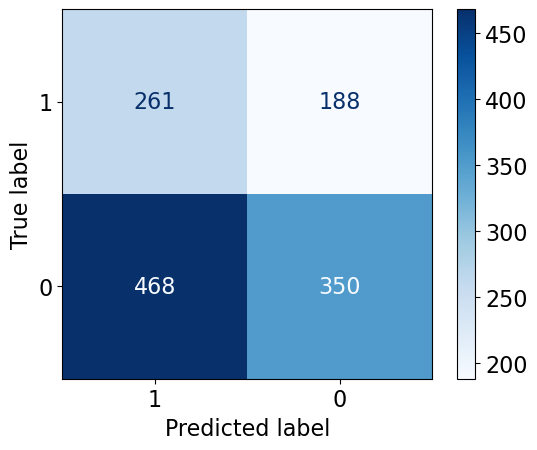

In [28]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    torch.cat(true_labels), 
    torch.cat(predictions), 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)